Depths for position 0: [0.63043478 0.45652174 0.13043478 0.13043478 0.         0.13043478
 0.08695652 0.67391304 0.63043478 0.         0.67391304 0.04347826
 0.93478261 0.         0.15217391 0.         1.         0.7173913
 0.47826087 0.82608696]
High depth indices: [ 0  7  8 10 12 16 17 19]
Angular spread (deg) among high depth vectors: 350.06
Low depth indices: [ 0  1  2  3  5  6  7  8 10 12 14 16 17 18 19]
Angular spread (deg) among low depth vectors: 531.33
Depths for position 1: [0.35416667 0.41666667 0.35416667 0.         0.         0.8125
 0.04166667 0.66666667 1.         0.72916667 0.         0.83333333
 0.5        0.625      0.         0.54166667 0.3125     0.97916667
 0.14583333 0.29166667]
High depth indices: [ 5  7  8  9 11 13 15 17]
Angular spread (deg) among high depth vectors: 13.14
Low depth indices: [ 0  1  2  5  7  8  9 11 12 13 15 16 17 18 19]
Angular spread (deg) among low depth vectors: 13.14
Depths for position 2: [0.76923077 0.92307692 0.20512821 0.         0.230

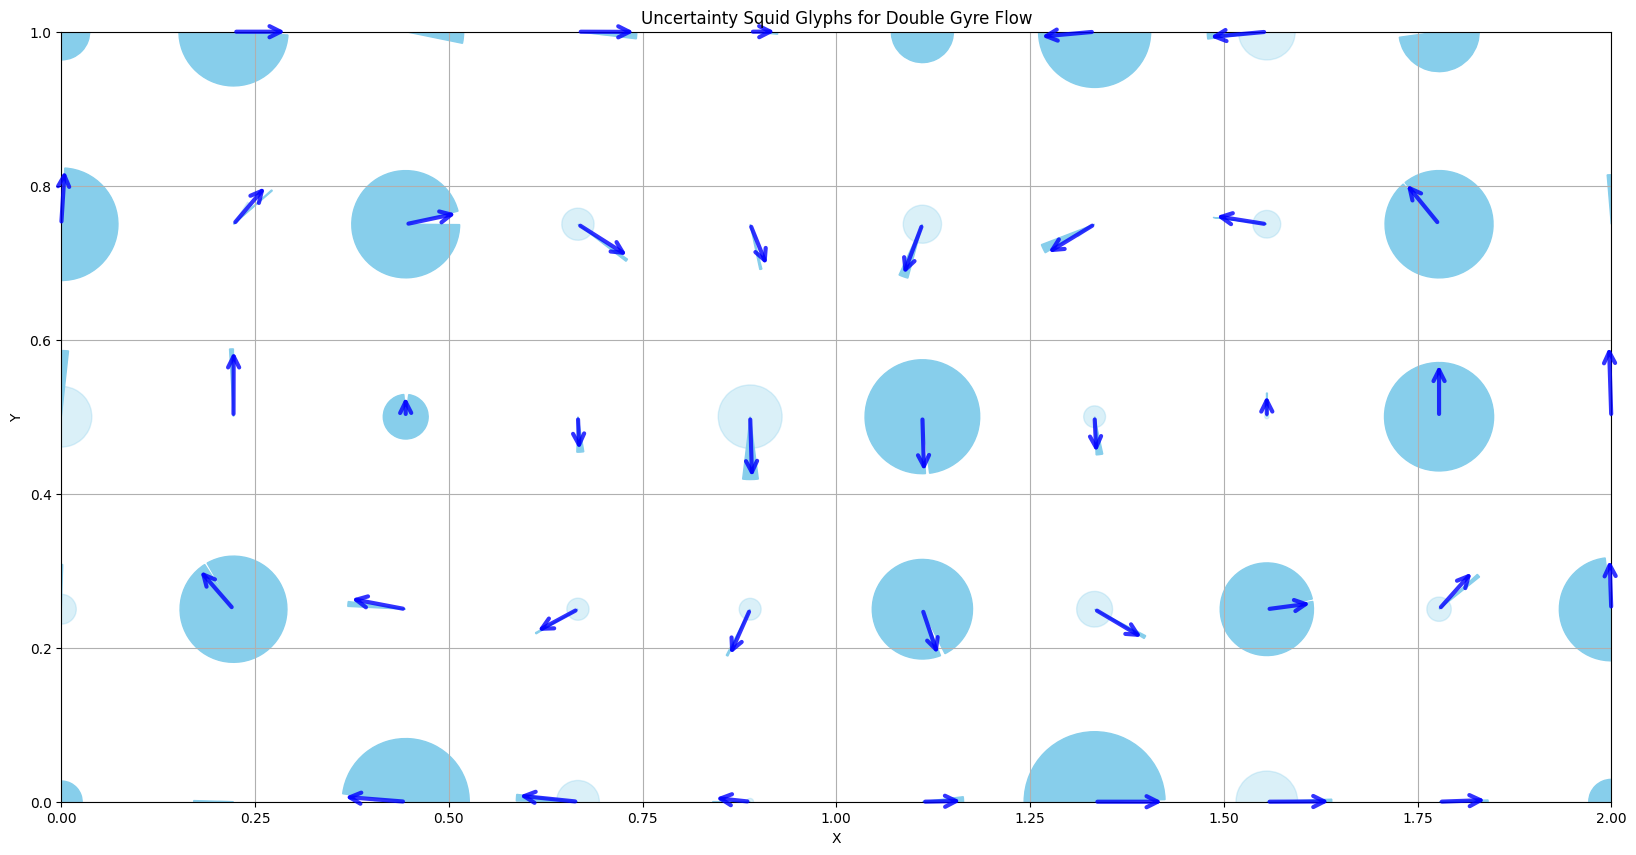

In [ ]:
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge


def pairwise_max_angles(vectors):
    """
    Calculate the angle (in degrees) between each pair of vectors in the input array.
    Uses arctan2 for robust angle calculation.
    vectors: numpy array of shape (n, 2)
    Returns: numpy array of shape (n, n) with angles in degrees
    """
    in_first_quadrant = False
    in_second_quadrant = False
    in_third_quadrant = False
    in_fourth_quadrant = False

    for i in range(len(vectors)):
        # Check if vector i is in the first quadrant (both components positive)
        if in_first_quadrant == False:
            in_first_quadrant = vectors[i, 0] > 0 and vectors[i, 1] > 0
        # Check if vector i is in the second quadrant (x negative, y positive)
        if in_second_quadrant == False:
            in_second_quadrant = vectors[i, 0] < 0 and vectors[i, 1] > 0
        # Check if vector i is in the third quadrant (both components negative)
        if in_third_quadrant == False:
            in_third_quadrant = vectors[i, 0] < 0 and vectors[i, 1] < 0
        # Check if vector i is in the fourth quadrant (x positive, y negative)
        if in_fourth_quadrant == False:
            in_fourth_quadrant = vectors[i, 0] > 0 and vectors[i, 1] < 0

    quadrant_count = sum([in_first_quadrant, in_second_quadrant, in_third_quadrant, in_fourth_quadrant])
    opposite_1_3 = in_first_quadrant and in_third_quadrant
    opposite_2_4 = in_second_quadrant and in_fourth_quadrant
    if quadrant_count >= 3 or opposite_2_4 or opposite_1_3:
        print("Vectors span at least 3 of the 4 quadrants.")

    else:
        print("Vectors do not span at least 3 quadrants.")

    n = vectors.shape[0]
    angles = np.zeros((n, n))
    max_angle = -np.inf
    max_pair = (None, None)
    for i in range(n):
        for j in range(n):
            v1 = vectors[i]
            v2 = vectors[j]
            norm1 = np.linalg.norm(v1)
            norm2 = np.linalg.norm(v2)
            if norm1 == 0 or norm2 == 0:
                angles[i, j] = np.nan
            else:
                # Compute the angle between v1 and v2 using arctan2 of the cross and dot product
                cross = v1[0]*v2[1] - v1[1]*v2[0]
                dot = np.dot(v1, v2)
                theta = np.arctan2(np.abs(cross), dot)
                angle_deg = np.degrees(theta)
                angles[i, j] = angle_deg
                if angle_deg > max_angle:
                    max_angle = angle_deg
                    max_pair = (i, j)
    return max_angle, max_pair


def angular_spread(vectors):
    """Calculate the angular spread and magnitude spread of a set of vectors.
    Input
        vectors: numpy array of shape (n, 2)
    Output
        angular_spread_deg: float, the angular spread in degrees
        magnitude_spread: float, the magnitude spread
        min_idx: int, index of the vector with the minimum angle
        max_idx: int, index of the vector with the maximum angle
    """
    # Calculate the angular spread (max-min angle from origin) and return indices
    angles_from_origin = np.arctan2(vectors[:, 1], vectors[:, 0])
    angles_unwrapped = np.unwrap(angles_from_origin)
    min_idx = np.argmin(angles_unwrapped)
    max_idx = np.argmax(angles_unwrapped)
    angular_spread = angles_unwrapped[max_idx] - angles_unwrapped[min_idx]
    angular_spread_deg = np.degrees(angular_spread)
    return angular_spread_deg, min_idx, max_idx


def magnitude_spread(vectors):
    """Calculate the magnitude spread of a set of vectors.
    Input
        vectors: numpy array of shape (n, 2)
    Output
        magnitude_spread: float, the magnitude spread
        min_mag_idx: int, index of the vector with the minimum magnitude
        max_mag_idx: int, index of the vector with the maximum magnitude
    """
    # Calculate the magnitude spread (max-min magnitude) and return indices
    magnitudes = np.linalg.norm(vectors, axis=1)
    min_mag_idx = np.argmin(magnitudes)
    max_mag_idx = np.argmax(magnitudes)
    magnitude_spread = magnitudes[max_mag_idx] - magnitudes[min_mag_idx]
    return magnitude_spread, min_mag_idx, max_mag_idx


def compute_vector_depths(vectors):
    """Compute the depth of each vector in the ensemble.
    Input
        vectors: numpy array of shape (n, 2)
    Output
        depths: numpy array of shape (n,), depth of each vector
    """
    n = vectors.shape[0]
    depths = np.zeros(n)
    # Calculate n choose 2 combinations of indices
    n = vectors.shape[0]
    pairs = list(combinations(np.arange(n), 2))

    # Compute depth for each vector
    for i in range(n):
        depth = 0
        for j, k in pairs:
            angle_i = np.arctan2(vectors[i, 1], vectors[i, 0])  
            angle_j = np.arctan2(vectors[j, 1], vectors[j, 0])
            angle_k = np.arctan2(vectors[k, 1], vectors[k, 0])
            mag_i = np.linalg.norm(vectors[i])
            mag_j = np.linalg.norm(vectors[j])
            mag_k = np.linalg.norm(vectors[k])
            # print(f"angle_i: {angle_i}, angle_j: {angle_j}, angle_k: {angle_k}")

            # Check if vector i is between vectors j and k and magnitude is also between
            if (angle_j < angle_i < angle_k or angle_k < angle_i < angle_j) and \
               (min(mag_j, mag_k) < mag_i < max(mag_j, mag_k)):
                depth += 1

        depths[i] = depth

    # scale depths between 0 and 1
    depths = (depths - depths.min()) / (depths.max() - depths.min())
    return depths


def get_squid_glyph_info(vectors, vector_depths, percentile1=0.5, percentile2=0.9):

    # Find index of vector with maximum depth
    max_depth_idx = np.argmax(vector_depths)
    # Find all indices where vector_depth > 1.0-percentile1
    high_depth_indices = np.where(vector_depths > 1.0-percentile1)[0]
    # Find all indices where vector_depth > 1.0-percentile2
    low_depth_indices = np.where(vector_depths > 1.0-percentile2)[0]
    mag_spread, min_mag_idx, max_mag_idx = magnitude_spread(vectors)
    median_mag = np.linalg.norm(vectors[max_depth_idx])
    median_angle = np.arctan2(vectors[max_depth_idx, 1], vectors[max_depth_idx, 0])

    if high_depth_indices.size > 0:
        high_depth_vectors = vectors[high_depth_indices]
        ang_spread_high, min_ang_idx_high, max_ang_idx_high = angular_spread(vectors[high_depth_indices])
        print(f"High depth indices: {high_depth_indices}")
        theta_high = np.array([[np.arctan2(vectors[min_ang_idx_high, 1], vectors[min_ang_idx_high, 0])], [np.arctan2(vectors[max_ang_idx_high, 1], vectors[max_ang_idx_high, 0])]])
        r_high = np.linalg.norm(vectors[min_mag_idx])
        min_angle_high = np.arctan2(vectors[min_ang_idx_high, 1], vectors[min_ang_idx_high, 0])
        max_angle_high = np.arctan2(vectors[max_ang_idx_high, 1], vectors[max_ang_idx_high, 0])
        print(f"Angular spread (deg) among high depth vectors: {ang_spread_high:.2f}")
    else:
        theta_high, r_high, min_angle_high, max_angle_high = (None, None, None, None)
        print("No vectors found in high_depth_indices.")

    if low_depth_indices.size > 0:
        low_depth_vectors = vectors[low_depth_indices]
        ang_spread_low, min_ang_idx_low, max_ang_idx_low = angular_spread(vectors[low_depth_indices])
        print(f"Low depth indices: {low_depth_indices}")
        theta_low = np.array([[np.arctan2(vectors[min_ang_idx_low, 1], vectors[min_ang_idx_low, 0])], [np.arctan2(vectors[max_ang_idx_low, 1], vectors[max_ang_idx_low, 0])]])
        r_low = np.linalg.norm(vectors[max_mag_idx])
        min_angle_low = np.arctan2(vectors[min_ang_idx_low, 1], vectors[min_ang_idx_low, 0])
        max_angle_low = np.arctan2(vectors[max_ang_idx_low, 1], vectors[max_ang_idx_low, 0])
        print(f"Angular spread (deg) among low depth vectors: {ang_spread_low:.2f}")
    else:
        theta_low, r_low, min_angle_low, max_angle_low = (None, None, None, None)
        print("No vectors found in low_depth_indices.")

    return theta_high, r_high, min_angle_high, max_angle_high, theta_low, r_low, min_angle_low, max_angle_low, median_mag, median_angle


def draw_wedges_with_arrow(ax, centers, theta1, theta2, mid_angle, r1, r2):
    """
    Draws multiple wedges with arrows.
    centers: numpy array of shape (n, 2)
    theta1: numpy array of shape (n, 2), each row [theta1_start, theta1_end] for the first wedge
    theta2: numpy array of shape (n, 2), each row [theta2_start, theta2_end] for the second wedge (arrowhead)
    mid_angle: iterable of length n, mid angle for arrow direction
    r1: float or iterable of length n, radius for the first wedge
    r2: float or iterable of length n, radius for the second wedge
    """
    n = centers.shape[0]
    # Support scalar or iterable for r1 and r2
    r1s = np.full(n, r1) if np.isscalar(r1) else np.asarray(r1)
    r2s = np.full(n, r2) if np.isscalar(r2) else np.asarray(r2)
    for i in range(n):
        center = centers[i]
        t1_start, t1_end = theta1[i]
        t2_start, t2_end = theta2[i]
        wedge = Wedge(center=center, r=r1s[i], theta1=t1_start, theta2=t1_end, facecolor='skyblue', edgecolor='skyblue', alpha=0.3)
        wedge2 = Wedge(center=center, r=r2s[i], theta1=t2_start, theta2=t2_end, facecolor='skyblue', edgecolor='skyblue', alpha=1.0)
        ax.annotate(
            '', 
            xy=(center[0] + r2s[i] * np.cos(np.deg2rad(mid_angle[i])), center[1] + r2s[i] * np.sin(np.deg2rad(mid_angle[i]))),
            xytext=center,
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=3, mutation_scale=20, alpha=0.8)
        )
        ax.add_patch(wedge)
        ax.add_patch(wedge2)

def uncertainty_squid_glyphs(positions, ensemble_vectors, percentil1, percentil2, scale=0.2, ax=None):
    """Draws uncertainty squid glyphs for the given positions and ensemble vectors.
    Input
    -----
    positions: numpy array of shape (n, 2)
        The positions of the squid glyphs.
    ensemble_vectors: numpy array of shape (n, m, 2)
        The ensemble vectors for each position.
    percentil1: float
        The first percentile for depth filtering.
    percentil2: float
        The second percentile for depth filtering.
    scale: float
        The scale factor for the glyphs.
    ax: matplotlib axis
        The axis to draw on. If None, a new figure and axis will be created.


    Output
    ------
    ax: matplotlib axis
        The axis with the drawn squid glyphs.
    """

    if ax is None:
        fig, ax = plt.subplots()
    num_positions, num_ens_members =ensemble_vectors.shape[0], ensemble_vectors.shape[1]
    theta1 = np.zeros((num_positions, 2))
    theta2 = np.zeros((num_positions, 2))
    mid_angle = np.zeros(num_positions)
    r1 = np.zeros(num_positions)
    r2 = np.zeros(num_positions)

    for i_pos in range(num_positions):
        # computer vector depths for ensemble_vectors[i_pos]
        depths = compute_vector_depths(ensemble_vectors[i_pos])
        print(f"Depths for position {i_pos}: {depths}")
        theta_high, r_high, min_angle_high, max_angle_high, theta_low, r_low, min_angle_low, max_angle_low, median_mag, median_angle = get_squid_glyph_info(ensemble_vectors[i_pos], depths, percentil1, percentil2)
        theta1[i_pos] = np.degrees([min_angle_high, max_angle_high]) if min_angle_high is not None else [0, 0]
        theta2[i_pos] = np.degrees([min_angle_low, max_angle_low]) if min_angle_low is not None else [0, 0]
        mid_angle[i_pos] = np.degrees(median_angle)
        r1[i_pos] = r_high * scale if r_high is not None else 0
        r2[i_pos] = r_low * scale if r_low is not None else 0

    draw_wedges_with_arrow(ax, positions, theta1, theta2, mid_angle, r1, r2)

    return ax


A = 0.1
omega = np.pi
epsilon = 0.25
def double_gyre(x, y, t=0):
    a = epsilon * np.sin(omega * t)
    b = 1 - 2 * a
    f = a * x**2 + b * x
    df_dx = 2 * a * x + b
    u = -np.pi * A * np.sin(np.pi * f) * np.cos(np.pi * y)
    v = np.pi * A * np.cos(np.pi * f) * np.sin(np.pi * y) * df_dx
    return u, v

fig2, ax2 = plt.subplots(figsize=(20, 10))
# Change domain to [0,2] x [0,1]
X, Y = np.meshgrid(np.linspace(0, 2, 10), np.linspace(0, 1, 5))
U, V = double_gyre(X, Y)
# Create ensemble data by perturbing vector magnitude and direction with Gaussian noise
n_ensemble = 20  # number of ensemble members
rng = np.random.default_rng(seed=42)

# Flatten the grid for easier perturbation
X_flat = X.flatten()
Y_flat = Y.flatten()
U_flat = U.flatten()
V_flat = V.flatten()
n_points = X_flat.size

# Compute magnitude and angle
mag = np.sqrt(U_flat**2 + V_flat**2)
angle = np.arctan2(V_flat, U_flat)

# Standard deviations for noise (tune as needed)
mag_noise_std = 0.20 * mag.max()
angle_noise_std = np.deg2rad(5)  # 5 degree std


n_ensemble = 20
ensemble_vectors = np.zeros((n_points, n_ensemble, 2))

for i in range(n_points):
    for j in range(n_ensemble):
        # Perturb magnitude and angle
        mag_perturbed = mag[i] + rng.normal(0, mag_noise_std)
        angle_perturbed = angle[i] + rng.normal(0, angle_noise_std)

        # Convert back to Cartesian coordinates
        ensemble_vectors[i, j] = [
            mag_perturbed * np.cos(angle_perturbed),
            mag_perturbed * np.sin(angle_perturbed)
        ]
positions = np.vstack((X_flat, Y_flat)).T
ax2 = uncertainty_squid_glyphs(positions, ensemble_vectors, 0.5, 0.95, ax=ax2)

plt.title("Uncertainty Squid Glyphs for Double Gyre Flow")
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()


# vectors = np.array([
#     [1, 1],
#     [0.9, 1.1],
#     [1.1, 0.8],
#     [0.8, 1.2],
#     [1.2, 1.0],
#     [-1,-1],
#     [-1, 1],
#     [-1, -1.5]
# ])

# for i, (x, y) in enumerate(vectors):
#     plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color=plt.cm.bwr(i / len(vectors)), label=f'Vector {i}')
# plt.title("Quiver plot of vectors at (0,0)")
# plt.axis('equal')
# plt.show()
# max_angle, max_pair = pairwise_max_angles(vectors)
# print(f"Max angle: {max_angle:.2f} degrees between vectors {max_pair[0]} and {max_pair[1]}")
# depths = compute_vector_depths(vectors)
# print("Depths of each vector:", depths)

In [ ]:
import numpy
from matplotlib.patches import Wedge


import matplotlib.pyplot as plt
# Double gyre vector field example and visualization
A = 0.1
omega = numpy.pi
epsilon = 0.25
def double_gyre(x, y, t=0):
    a = epsilon * numpy.sin(omega * t)
    b = 1 - 2 * a
    f = a * x**2 + b * x
    df_dx = 2 * a * x + b
    u = -numpy.pi * A * numpy.sin(numpy.pi * f) * numpy.cos(numpy.pi * y)
    v = numpy.pi * A * numpy.cos(numpy.pi * f) * numpy.sin(numpy.pi * y) * df_dx
    return u, v

fig2, ax2 = plt.subplots()
# Change domain to [0,2] x [0,1]
X, Y = numpy.meshgrid(numpy.linspace(0, 2, 10), numpy.linspace(0, 1, 10))
U, V = double_gyre(X, Y)
# Create ensemble data by perturbing vector magnitude and direction with Gaussian noise
n_ensemble = 20  # number of ensemble members
rng = numpy.random.default_rng(seed=42)

# Flatten the grid for easier perturbation
X_flat = X.flatten()
Y_flat = Y.flatten()
U_flat = U.flatten()
V_flat = V.flatten()
n_points = X_flat.size

# Compute magnitude and angle
mag = numpy.sqrt(U_flat**2 + V_flat**2)
angle = numpy.arctan2(V_flat, U_flat)

# Standard deviations for noise (tune as needed)
mag_noise_std = 0.20 * mag.max()
angle_noise_std = numpy.deg2rad(10)  # 10 degree std


# Store ensemble members as list of (U_ens, V_ens)
ensemble = []
for i in range(n_ensemble):
    mag_perturbed = mag + rng.normal(0, mag_noise_std, size=n_points)
    angle_perturbed = angle + rng.normal(0, angle_noise_std, size=n_points)
    U_ens = mag_perturbed * numpy.cos(angle_perturbed)
    V_ens = mag_perturbed * numpy.sin(angle_perturbed)
    # Reshape to original grid shape
    U_ens = U_ens.reshape(U.shape)
    V_ens = V_ens.reshape(V.shape)
    ensemble.append((U_ens, V_ens))

# Example: plot the first ensemble member
ax2.quiver(X, Y, ensemble[0][0], ensemble[0][1], color='orange', scale=5, alpha=0.5, label='Ensemble member 0')

# Plot original field for reference
ax2.quiver(X, Y, U, V, color='red', scale=5, alpha=0.7, label='Original')
ax2.set_title("Double Gyre Vector Field with Ensemble Perturbations")
ax2.set_aspect('equal')
ax2.legend()

# Compute magnitude for each ensemble member
ensemble_mags = [numpy.sqrt(Ue**2 + Ve**2) for Ue, Ve in ensemble]
ensemble_mags_stack = numpy.stack(ensemble_mags, axis=0)  # shape: (n_ensemble, grid_shape...)

# Compute min, median, max over ensemble axis (axis=0)
mag_min = numpy.min(ensemble_mags_stack, axis=0)
mag_median = numpy.median(ensemble_mags_stack, axis=0)
mag_max = numpy.max(ensemble_mags_stack, axis=0)

# set centers to coordinate X, Y
centers = numpy.column_stack((X_flat, Y_flat))
r1 = mag_min
r2 = mag_max

fig, ax = plt.subplots()
def draw_wedges_with_arrow(ax, centers, theta1, theta2, mid_angle, r1, r2):
    """
    Draws multiple wedges with arrows.
    centers: numpy array of shape (n, 2)
    theta1: numpy array of shape (n, 2), each row [theta1_start, theta1_end] for the first wedge
    theta2: numpy array of shape (n, 2), each row [theta2_start, theta2_end] for the second wedge (arrowhead)
    mid_angle: iterable of length n, mid angle for arrow direction
    r1: float or iterable of length n, radius for the first wedge
    r2: float or iterable of length n, radius for the second wedge
    """
    n = centers.shape[0]
    # Support scalar or iterable for r1 and r2
    r1s = numpy.full(n, r1) if numpy.isscalar(r1) else numpy.asarray(r1)
    r2s = numpy.full(n, r2) if numpy.isscalar(r2) else numpy.asarray(r2)
    for i in range(n):
        center = centers[i]
        t1_start, t1_end = theta1[i]
        t2_start, t2_end = theta2[i]
        wedge = Wedge(center=center, r=r1s[i], theta1=t1_start, theta2=t1_end, facecolor='skyblue', edgecolor='skyblue', alpha=0.3)
        wedge2 = Wedge(center=center, r=r2s[i], theta1=t2_start, theta2=t2_end, facecolor='skyblue', edgecolor='skyblue', alpha=1.0)
        ax.annotate(
            '', 
            xy=(center[0] + r2s[i] * numpy.cos(numpy.deg2rad(mid_angle[i])), center[1] + r2s[i] * numpy.sin(numpy.deg2rad(mid_angle[i]))),
            xytext=center,
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=3, mutation_scale=20, alpha=0.8)
        )
        ax.add_patch(wedge)
        ax.add_patch(wedge2)

# Example usage with values:
draw_wedges_with_arrow(
    ax,
    centers=centers,
    theta1=theta1,
    theta2=theta2,
    mid_angle=mid_angle,
    r1=[0.3, 0.4],
    r2=[0.4, 0.5]
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()